# Confusion Matrix and Classification Report — Machine Learning Analysis

## Introduction

This notebook focuses on evaluating a binary classification model and understanding how its predictions can be interpreted using a confusion matrix and classification metrics.

The Breast Cancer dataset from Scikit-learn is used to train a Logistic Regression model. After making predictions, the model is evaluated using accuracy, precision, recall, specificity, F1-score and ROC-AUC.

The effect of changing the classification threshold is also examined at the end of the analysis.

## Objectives

The main objectives of this activity are:

- To divide the dataset into training and testing sets.
- To build a Logistic Regression classification model.
- To understand the four outcomes of a confusion matrix.
- To calculate and interpret classification metrics.
- To generate a classification report.
- To evaluate the model using ROC-AUC and an ROC curve.
- To examine how different classification thresholds affect model performance.

## 1. Importing the Required Libraries

The libraries below are used for loading the dataset, preparing the data, training the Logistic Regression model, creating visualisations, and calculating the required evaluation metrics.

In [30]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
        ConfusionMatrixDisplay,
            classification_report,
                accuracy_score,
                    precision_score,
                        recall_score,
                            f1_score,
                                roc_auc_score,
                                    roc_curve
                                    )







## 2. Loading the Dataset

The Breast Cancer dataset is loaded directly from Scikit-learn. It contains observations belonging to two target classes, making it suitable for demonstrating binary classification and its evaluation metrics.

In [31]:
data = load_breast_cancer(as_frame=True)

X = data.data
y = data.target



### 2.1 Initial Inspection

A quick inspection of the feature matrix and target variable is performed before splitting the data.

In [32]:
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

X.head()

Feature shape: (569, 30)
Target shape: (569,)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### Observation

The dataset contains 569 observations and 30 numerical features. The target variable is binary, which makes the dataset suitable for the Logistic Regression classification task used in this activity.

## 3. Train-Test Split

The data is divided into training and testing subsets. A 75:25 split is used, with stratification to maintain a similar proportion of the two target classes in both subsets.

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
      X,
          y,
              test_size=0.25,
                  random_state=42,
                      stratify=y
                      )


### 3.1 Checking the Split

The dimensions of the training and testing sets are displayed to confirm that the data has been divided as expected.

In [34]:
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (426, 30)
Testing features: (143, 30)
Training target: (426,)
Testing target: (143,)


### Observation

The training set will be used to fit the model, while the test set is kept separate so that the final predictions can be evaluated on observations that were not used during training.

## 4. Building the Logistic Regression Model

Logistic Regression is used as the binary classification model for this activity.

Because the predictor variables are measured on different scales, StandardScaler is included in a pipeline before the classifier.

In [35]:
model = Pipeline([
      ("scaler", StandardScaler()),
          ("classifier", LogisticRegression(max_iter=2000))
          ])

### 4.1 Training the Model

The Logistic Regression model is fitted using the training data.

In [36]:
model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', LogisticRegression(max_iter=2000))])

### 4.2 Generating Predictions

Two outputs are generated from the trained model. The predicted class is used for the confusion matrix and classification metrics, while the predicted probability is used for ROC-AUC and threshold analysis.

In [37]:
pred = model.predict(X_test)

prob = model.predict_proba(X_test)[:, 1]

## 5. Confusion Matrix

A confusion matrix compares the actual target values with the classes predicted by the model.

For a binary classifier, the four possible outcomes are:

- **True Positive (TP):** a positive case correctly predicted as positive.
- **True Negative (TN):** a negative case correctly predicted as negative.
- **False Positive (FP):** a negative case incorrectly predicted as positive.
- **False Negative (FN):** a positive case incorrectly predicted as negative.

### 5.1 Creating the Confusion Matrix

In [38]:
cm = confusion_matrix(y_test, pred)

print("Confusion Matrix:")
print(cm)



Confusion Matrix:
[[52  1]
 [ 1 89]]


### 5.2 Confusion Matrix Visualization

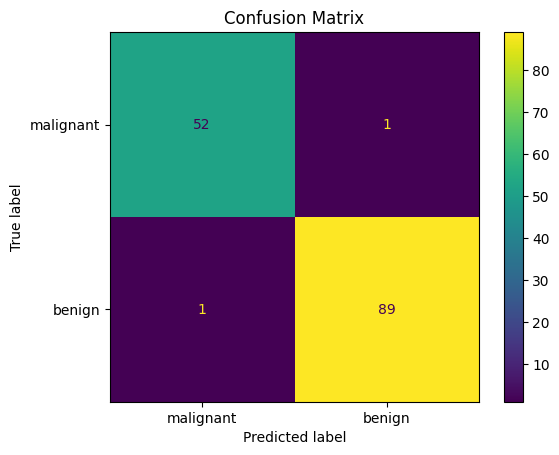

In [39]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

### Observation

The model correctly classified 52 negative cases and 89 positive cases. There was only 1 false positive and 1 false negative in the test set, so the number of incorrect predictions was very small.

## 6. Understanding the Confusion Matrix

The four values in the confusion matrix can be extracted separately so that the model's correct predictions and errors can be examined more clearly.

In [40]:
tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)



True Negatives : 52
False Positives: 1
False Negatives: 1
True Positives : 89


### 6.1 Interpreting TP, TN, FP and FN

The four values describe different types of predictions:

- **True Negatives (TN):** negative cases correctly identified by the model.
- **False Positives (FP):** negative cases incorrectly classified as positive.
- **False Negatives (FN):** positive cases incorrectly classified as negative.
- **True Positives (TP):** positive cases correctly identified by the model.

These values form the basis for several of the evaluation metrics used below.

## 7. Classification Metrics

The model is evaluated using several metrics derived from its predictions. Looking at multiple metrics gives a more complete picture of model performance than accuracy alone.

### 7.1 Calculating the Metrics

The main classification metrics are calculated from the actual and predicted values.

In [41]:
accuracy = accuracy_score(y_test, pred)
precision = precision_score(y_test, pred)
recall = recall_score(y_test, pred)
specificity = tn / (tn + fp)
f1 = f1_score(y_test, pred)
roc_auc = roc_auc_score(y_test, prob)

metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall / Sensitivity": recall,
    "Specificity": specificity,
    "F1 Score": f1,
    "ROC-AUC": roc_auc
}

display(pd.Series(metrics))

,0
Accuracy,0.986014
Precision,0.988889
Recall / Sensitivity,0.988889
Specificity,0.981132
F1 Score,0.988889
ROC-AUC,0.997694


### 7.2 What the Metrics Mean

- **Accuracy** measures the overall proportion of correct predictions.
- **Precision** measures how many of the observations predicted as positive were actually positive.
- **Recall / Sensitivity** measures how many of the actual positive observations were correctly identified.
- **Specificity** measures how well the model identifies the negative class.
- **F1-score** combines precision and recall into a single measure.
- **ROC-AUC** measures how effectively the model separates the two classes across different classification thresholds.

### Observation

The model performs strongly across all of the main evaluation metrics. Accuracy is approximately 98.6%, while precision, recall and F1-score are all close to 98.9%. The ROC-AUC of approximately 0.998 also indicates that the model separates the two classes very effectively on this test set.

## 8. Classification Report

The classification report provides precision, recall and F1-score for each target class. This allows the performance of the classifier to be examined separately for the two classes.

In [42]:
print(
      classification_report(
              y_test,
                      pred,
                              target_names=data.target_names,
                                      zero_division=0
                                          )
                                          )




              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        53
      benign       0.99      0.99      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



### Observation

The classification report shows that performance can differ between the two target classes. Comparing precision and recall for each class helps identify whether the model is more likely to make one type of classification error than another.

## 9. ROC Curve and ROC-AUC

The ROC curve shows how the true-positive rate changes relative to the false-positive rate as the classification threshold is varied.

The ROC-AUC value provides a single summary of the model's ability to distinguish between the two classes.

### 9.1 Generating the ROC Curve

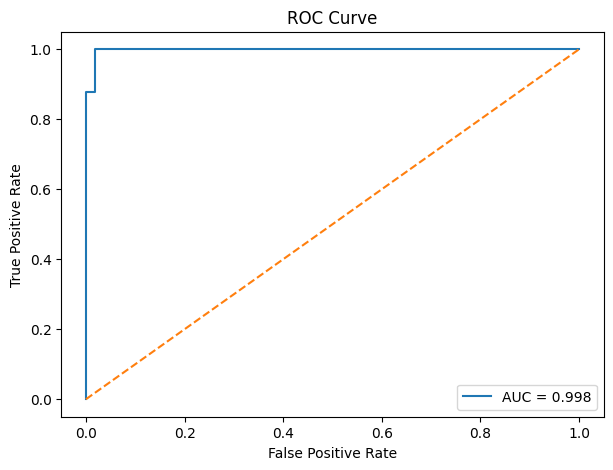

In [43]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

### Observation

The ROC curve lies close to the upper-left region of the graph, and the AUC is approximately 0.998. This indicates very strong separation between the two target classes for the test data.

## 10. Classification Threshold Analysis

Logistic Regression produces probabilities before a final class label is assigned. The classification threshold determines how those probabilities are converted into predictions.

The default threshold is generally 0.50, but changing it can alter the balance between precision, recall and other evaluation measures.

### 10.1 Testing Different Thresholds

Several classification thresholds are tested to see how the model's performance changes.

In [44]:
# Experiment with different classification thresholds
thresholds_to_try = [0.30, 0.40, 0.50, 0.60, 0.70]

rows = []

for threshold in thresholds_to_try:
    threshold_predictions = (
        prob >= threshold
    ).astype(int)

    rows.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_test,
            threshold_predictions
        ),
        "Precision": precision_score(
            y_test,
            threshold_predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            threshold_predictions,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test,
            threshold_predictions,
            zero_division=0
        )
    })

threshold_results = pd.DataFrame(rows)
display(threshold_results)

,Threshold,Accuracy,Precision,Recall,F1 Score
0,0.3,0.979021,0.967742,1.000000,0.983607
1,0.4,0.986014,0.988889,0.988889,0.988889
2,0.5,0.986014,0.988889,0.988889,0.988889
3,0.6,0.958042,0.988372,0.944444,0.965909
4,0.7,0.951049,0.988235,0.933333,0.960000


### 10.2 Threshold Analysis

The table shows how changing the threshold affects accuracy, precision, recall and F1-score.

A lower threshold generally makes it easier for an observation to be classified as positive, while a higher threshold makes the model more conservative about assigning the positive class.

### Observation

The threshold results show that the model performs similarly at thresholds of 0.40 and 0.50, with accuracy of about 98.6% and F1-score of about 0.989.

At a threshold of 0.30, recall reaches 1.00, meaning all positive cases in the test set are identified, although precision decreases slightly.

As the threshold increases to 0.60 and 0.70, recall falls to 0.944 and 0.933 respectively. This shows how increasing the threshold makes the model more conservative when assigning the positive class.

## 11. Overall Interpretation

The Logistic Regression model provides a complete example of how binary classification predictions can be evaluated beyond simply checking whether each prediction is correct.

The confusion matrix identifies the four types of outcomes, while the classification metrics summarise different aspects of model performance. The ROC curve and threshold experiment then show how the model behaves when the decision boundary is changed.

## 12. Conclusion

This activity demonstrated the evaluation of a binary classification model using the Breast Cancer dataset.

A Logistic Regression model was trained after scaling the predictor variables, and its predictions were examined using a confusion matrix and classification report. Accuracy, precision, recall, specificity, F1-score and ROC-AUC were used to evaluate different aspects of its performance.

The threshold analysis also showed that changing the classification threshold can affect the balance between precision and recall. This demonstrates why the choice of threshold should depend on the requirements of the classification problem rather than automatically relying on a single value.

## 13. Practice Questions

The following questions are included to reinforce the main concepts covered in this activity.

1. Which error type is more costly in a screening problem: false positive or false negative?

2. Why can accuracy be misleading with imbalanced data?

3. Explain the relationship between precision, recall and F1-score.

4. What happens when the classification threshold is increased?